In [ ]:
import os
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler

# VERİ YÜKLEME
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
data_path = os.path.join(BASE_DIR, "data", "stock_data.csv")

df = pd.read_csv(data_path, header=[0,1], index_col=0)
df_close = df["Close"]
df_close.columns = ["AAPL","AMZN","GOOG","MSFT","TSLA"]
df_close = df_close.apply(pd.to_numeric, errors="coerce").dropna()
df_close.index = pd.to_datetime(df_close.index)

# FEATURE FONKSİYONU
def create_features(ts):
    df_feat = pd.DataFrame({"y": ts})

    for lag in [1,2,3,5,7,14]:
        df_feat[f"lag_{lag}"] = ts.shift(lag)

    for r in [3,7,14,21]:
        df_feat[f"mean_{r}"] = ts.shift(1).rolling(r).mean()
        df_feat[f"std_{r}"] = ts.shift(1).rolling(r).std()

    df_feat["return_1"] = ts.pct_change(1)
    df_feat["return_5"] = ts.pct_change(5)

    df_feat = df_feat.dropna()
    return df_feat

# WALK-FORWARD FORECAST
def walk_forward_forecast(ts, window=504, step=63):
    feat = create_features(ts)
    results = []

    for start in range(window, len(feat), step):
        train = feat.iloc[start-window:start]
        test = feat.iloc[start:start+step]

        X_train, y_train = train.drop("y", axis=1), train["y"]
        X_test, y_test = test.drop("y", axis=1), test["y"]

        # Scaling
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        model = XGBRegressor(
            objective="reg:squarederror",
            n_estimators=800,
            learning_rate=0.03,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            verbosity=0
        )
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        results.append((y_test.values, preds, y_test.index))

    # Birleştir
    actual = np.concatenate([r[0] for r in results])
    forecast = np.concatenate([r[1] for r in results])
    dates = np.concatenate([r[2] for r in results])

    rmse = mean_squared_error(actual, forecast, squared=False)
    mape = mean_absolute_percentage_error(actual, forecast) * 100

    return actual, forecast, dates, rmse, mape

# Tüm hisseler
results = {}
for col in df_close.columns:
    actual, forecast, dates, rmse, mape = walk_forward_forecast(df_close[col], window=504, step=63)
    results[col] = {"actual": actual, "forecast": forecast, "dates": dates, "rmse": rmse, "mape": mape}
    print(col, rmse, mape)


c:\Users\esram\OneDrive\Desktop\esrabecode\portfolio-forecasting\venv\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


AAPL 8.25100524612211 3.0478628231041682


c:\Users\esram\OneDrive\Desktop\esrabecode\portfolio-forecasting\venv\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


AMZN 9.938014680863416 3.5815183232788894


c:\Users\esram\OneDrive\Desktop\esrabecode\portfolio-forecasting\venv\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


GOOG 12.126460081966087 3.503219021791194


c:\Users\esram\OneDrive\Desktop\esrabecode\portfolio-forecasting\venv\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


MSFT 15.071905087006202 2.6806032704150087
TSLA 33.26607518815179 6.76694216358383


c:\Users\esram\OneDrive\Desktop\esrabecode\portfolio-forecasting\venv\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(



 Grafik kaydedildi: walk_forward_results.png


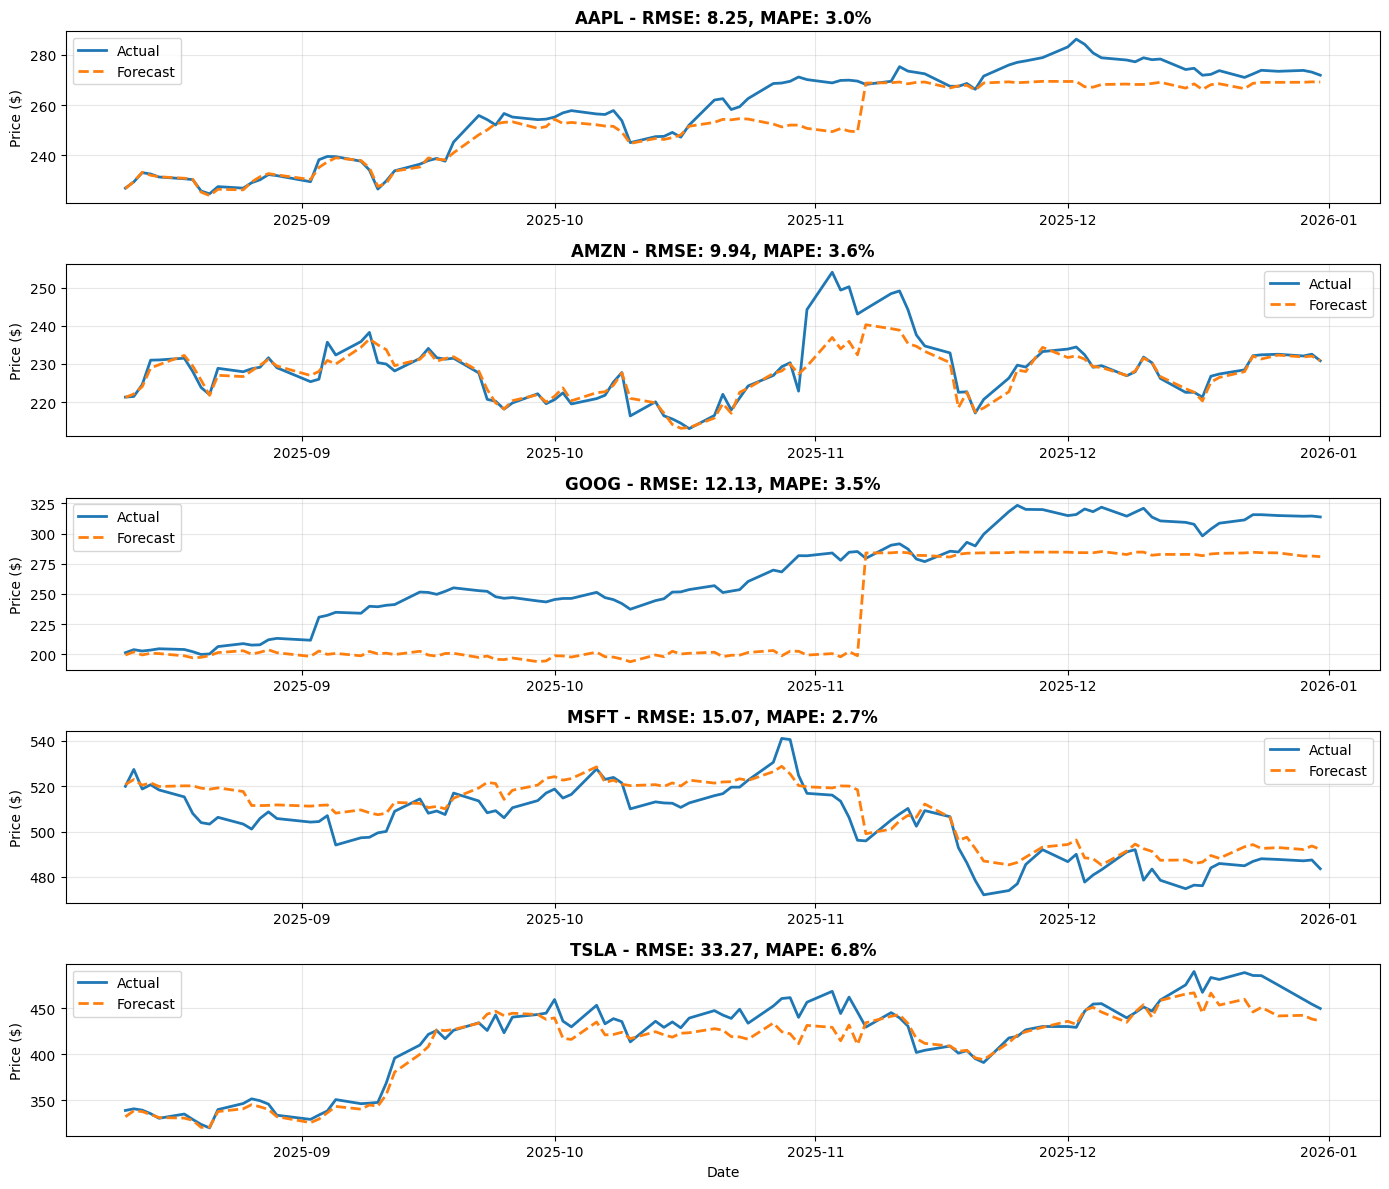

In [5]:

# GRAFİKLER
# =========================
fig, axes = plt.subplots(5, 1, figsize=(14, 12))

for idx, (col, res) in enumerate(results.items()):
    show_days = 100

    axes[idx].plot(res['dates'][-show_days:], res['actual'][-show_days:], label='Actual', linewidth=2)
    axes[idx].plot(res['dates'][-show_days:], res['forecast'][-show_days:], label='Forecast', linestyle='--', linewidth=2)

    axes[idx].set_title(f"{col} - RMSE: {res['rmse']:.2f}, MAPE: {res['mape']:.1f}%", fontsize=12, fontweight='bold')
    axes[idx].legend(loc='best')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_ylabel('Price ($)')

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.savefig('walk_forward_results.png', dpi=300, bbox_inches='tight')
print("\n Grafik kaydedildi: walk_forward_results.png")
plt.show()